# Predicting Online Purchasing Behaviour Using LASSO Logistic Regression

## Summary

In this project we try to predict whether an online shopping session will end in a purchase. That’s useful for understanding which users are likely to buy and for supporting efforts on how to improve conversion rates and user experience. <br>

We use the UCI Online Shoppers Purchasing Intention dataset. It’s public and has about 12,330 sessions. Each row is one session, and we have information on how many admin vs product pages they saw, time on site, bounce and exit rates, and session data like month and whether it was a weekend. The target variable is Revenue which is a binary variable, indicating whether the session ended in a purchase. We downloaded the data from the web, cleaned it up (factors, missing values, etc.), and did an 80/20 train–test split. <br>

We did some EDA with summary tables and visualizations, then fit a Lasso logistic regression and looked at the confusion matrix and ROC curve. <br>

The model gets 0.926 AUC and 90% accuracy on the test set. It’s really good at flagging non-buyers (specificity around 96%) but not as good at catching buyers (sensitivity about 57%). So it’s better at “no” than “yes.” McNemar’s test says model’s predictions are significantly better than the no-information rate, so the model is useful despite the class imbalance.

## Introduction

Understanding what drives a visitor to complete a purchase is a central challenge in e-commerce. While generating web traffic is relatively easy, converting visits into sales relies on a complex combination of browsing behavior, timing, and user intent. Being able to predict whether a given session (before it ends) will result in revenue would enable online retailers to intervene in real time, personalize experiences, and allocate marketing resources more effectively.

In this project, we aim to answer the question: Can we predict whether an online shopping session will result in a purchase based on the behavioral and contextual features recorded during that session?

To address this, we utilize the Online Shoppers Purchasing Intention Dataset (Sakar et al., 2019), sourced from the UCI Machine Learning Repository. This dataset contains 12,330 sessions collected from an e-commerce website over the course of one year. Each session is characterized by 17 features, which fall into three categories: page interaction metrics (e.g., the number of product-related pages visited and the time spent on each page type), web analytics signals (e.g., bounce rate, exit rate, and page value), and session context (e.g., month, whether the visit occurred on a weekend, visitor type, operating system, browser, region, and traffic source). The binary target variable, "Revenue," indicates whether the session ended in a transaction.

The dataset exhibits a notable class imbalance: approximately 84.5% of sessions did not result in a purchase, with only 15.5% ending in revenue. This imbalance is common in real-world e-commerce data and must be considered when evaluating model performance.

We frame this as a binary classification problem and train a LASSO logistic regression model using the glmnet package in R. LASSO (Least Absolute Shrinkage and Selection Operator) is chosen for its ability to perform automatic feature selection by shrinking less informative coefficients to zero. This capability is particularly valuable given the mix of numeric, ordinal, and high-cardinality categorical features present in the dataset. 

Before modeling, we conduct exploratory data analysis to assess feature distributions, class balance, and the relationships between key predictors and purchase outcomes. Categorical features with sparse levels are consolidated into an "Other" category, and right-skewed numeric features are log-transformed to reduce the impact of extreme outliers. The optimal regularization parameter, λ, is selected through cross-validated AUC.

We evaluate model performance using the AUC-ROC on a held-out test set (20% of the data), along with a confusion matrix to examine precision and recall for the minority (purchase) class.

## Methods and Results

### Imports

In [1]:
library(tidyverse)
library(glmnet)
library(ucimlrepo)
library(scales)
library(pROC)
library(caret)

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is m

### Load Data

To start off the analysis, we first need to load all the data from the internet. We will also split the data into features and targets right now for convenience.

In [2]:
# Load data from internet
zip_url <- "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip"
temp <- tempfile()
download.file(zip_url, temp)
unzip(temp, files = "online_shoppers_intention.csv", exdir = tempdir())
csv_path <- file.path(tempdir(), "online_shoppers_intention.csv")
raw_shoppers_data <- read_csv(csv_path)

raw_shoppers_features <- raw_shoppers_data %>% select(-Revenue)
raw_shoppers_targets <- raw_shoppers_data %>% select(Revenue)

Rows: 12330 Columns: 18
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Month, VisitorType
dbl (14): Administrative, Administrative_Duration, Informational, Informatio...
lgl  (2): Weekend, Revenue

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Let us quickly get a brief overview of the data to make sure it was loaded properly.

In [3]:
dim(raw_shoppers_features)
dim(raw_shoppers_targets)

[1] 12330    17

[1] 12330     1

### Dataset Description

With the data loaded successfully, we can examine the available features. This information is referenced from the official data source (UCI Machine Learning Repository: Online Shoppers Purchasing Intention Dataset). <br>Each row/data point represents one user session. 

**Table 1** Numerical Features

| Feature  | Type | Feature Description |
|----------------|-------------|------------------------|
| Administrative  | Integer | Number of administrative pages viewed per session |
| Administrative_Duration  | Integer | Total time spent on administrative pages per session |
| Informational  | Integer | Number of informational pages viewed per session |
| Informational_Duration  | Integer | Total time spent on informational pages per session |
| ProductRelated  | Integer | Number of product related pages viewed per session |
| ProductRelated_Duration  | Continuous | Number of product related pages viewed per session |
| BounceRates  | Continuous | Inverse of engagement rate (From Google Analytics) |
| ExitRates  | Continuous | Last page before stopping the user session (From Google Analytics) |
| PageValues  |  Integer | Average value each page contributes to the user session (From Google Analytics) |
| SpecialDay  | Integer | Closeness of the site visited date to a "special date" where purchase are more likely |

**Table 2** Categorical Features

| Feature  | Feature Description |
|----------------|-------------|
| Month  | Month of session |
| OperatingSystems | Operating system used for session |
| Browser  | Browser used for session |
| Region | Geographic region of session |
| TrafficType | Traffic source of session (banner, direct, SMS, etc.) |
| VisitorType | Visitor type of session (New, Returning, etc.) |
| Weekend  | Binary value indicating the session occurred on a weekend |

**Table 3** Target Variable

| Target Variable  | Variable Description |
|----------------|-------------|
| Revenue  | Binary class label indicating whether the user session ended in a purchase |

Knowing the expected data types of each feature, we can proceed with data cleaning to prepare for EDA and analysis.

### Dataset Cleaning

To start off we can do the following for all categorical features: 
- Convert to factors
- Drop missing columns denoted by "na"
- Remove unused factor levels
<br>
These are simple transformations that can be performed on both training and test data.

In [4]:
# Categorical feature cleaning
shoppers_features <- raw_shoppers_features %>% 
    mutate(
        Month = as.factor(Month),
        OperatingSystems = as.factor(OperatingSystems),
        Browser = as.factor(Browser),
        TrafficType = as.factor(TrafficType),
        VisitorType = as.factor(VisitorType),
        Weekend = as.factor(Weekend),
        Region = as.factor(Region)) %>%
    drop_na() %>% 
    droplevels()

shoppers_targets <- raw_shoppers_targets %>% 
    mutate(
        Revenue = ifelse(Revenue == "TRUE", "Yes", "No"),
        Revenue = as.factor(Revenue)) %>%
    drop_na() %>%
    droplevels()

The following transformations rely on peering into the data itself. As such, we must split the data into training and testing splits. <br> We will use a standard split 80:20 split ratio for training to test data as well as a random seed to ensure reproducible results.

In [5]:
# Split train and test
set.seed(310)

split_ratio = 0.8
shoppers_size = nrow(shoppers_features)
train_idx <- sample(1:shoppers_size, split_ratio * shoppers_size)

shoppers_features_train <- shoppers_features[train_idx, ]
shoppers_features_test <- shoppers_features[-train_idx, ]

shoppers_targets_train <- shoppers_targets[train_idx, ]
shoppers_targets_test <- shoppers_targets[-train_idx, ]

shoppers_train <- bind_cols(shoppers_features_train, shoppers_targets_train)
shoppers_test <- bind_cols(shoppers_features_test, shoppers_targets_test)

With the data split, we are free to explore the training data.<br>
Let us start with examining summary statistics for numerical variables. 

In [6]:
summary_shoppers_features_train <- shoppers_features_train %>%
    select(where(is.numeric)) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "val") %>%
    group_by(variable) %>%
    summarise(
        n = sum(!is.na(val)),
        missing = sum(is.na(val)),
        mean = round(mean(val, na.rm = TRUE), 3),
        sd = round(sd(val, na.rm = TRUE), 3),
        min = round(min(val, na.rm = TRUE), 3),
        median = round(median(val, na.rm = TRUE), 3),
        max = round(max(val, na.rm = TRUE), 3)
    )

cat("Table 4: Summary Statistics of Numerical Variables in Online Shoppers Training Data\n")
summary_shoppers_features_train

Table 4: Summary Statistics of Numerical Variables in Online Shoppers Training Data


variable,n,missing,mean,sd,min,median,max
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Administrative,9864,0,2.327,3.335,0,1.000,27.000
Administrative_Duration,9864,0,81.441,179.200,0,8.000,3398.750
BounceRates,9864,0,0.022,0.048,0,0.003,0.200
ExitRates,9864,0,0.043,0.048,0,0.025,0.200
Informational,9864,0,0.509,1.282,0,0.000,24.000
Informational_Duration,9864,0,34.943,142.935,0,0.000,2549.375
PageValues,9864,0,5.857,18.180,0,0.000,361.764
ProductRelated,9864,0,31.889,44.135,0,18.000,705.000
ProductRelated_Duration,9864,0,1200.199,1935.239,0,607.778,63973.522


Some observations from the summary statistics:
- No missing values
- The popularity of the page types are as follows: Informational < Administrative < ProductRelated
- BounceRates, ExitRates, and SpecialDay have fairly high standard deviation (~20% of max), could be an issue
<br>
Next we would like to examine the label imbalance for the target labels

In [7]:
# Label imbalance 
shoppers_target_imbalance_train <- shoppers_targets_train %>% 
    count(Revenue, name = "n") %>% 
    mutate(prop = percent(n / sum(n), accuracy = 0.1))

cat("Table 5: Distribution of Revenue Training Target Labels")
shoppers_target_imbalance_train

Table 5: Distribution of Revenue Training Target Labels

Revenue,n,prop
<fct>,<int>,<chr>
No,8331,84.5%
Yes,1533,15.5%


The target label imbalance is quite high which could affect the analysis results. There are way more sessions resulting in no purchase which is expected. <br>
In order to improve the numeric data quality, we may be able to relabel some numerical features as catagorical. One such feature could be `SpecialDay` since the interval between holidays is pretty short. <br>
We can determine this through examining the sparsity and number of unique values for each numerical feature.

In [8]:
# Get sparsity and unique values of all numerical features
unique_counts_shoppers_train <- shoppers_features_train %>% 
    select(where(is.numeric)) %>%
    summarise(across(everything(), ~ length(unique(.))))

zero_counts_shoppers_train <- shoppers_features_train %>% 
    select(where(is.numeric)) %>%
    summarise(across(everything(), ~ sum(. == 0)))

cat("Table 6: Unique Values for Numeric Features")
unique_counts_shoppers_train
cat("Table 7: Zero counts for Numeric Features")
zero_counts_shoppers_train

Table 6: Unique Values for Numeric Features

Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
27,2816,16,1061,290,7838,1606,3957,2184,6


Table 7: Zero counts for Numeric Features

Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
4597,4707,7749,7936,30,592,4433,58,7661,8857


It appears that the features `Administrative`, `Informational`, and `SpecialDay` have very few unique values. <br>
We will turn these into categorical features to preserve the linearity assumption in logistic regression.

In [9]:
# Convert unique numerical features into categorical
num_to_cat_shoppers_train <- shoppers_train %>%
    mutate(
        Administrative = as.factor(Administrative),
        Informational = as.factor(Informational),
        SpecialDay = as.factor(SpecialDay)
    )

# Apply the same transformation to the test data
num_to_cat_shoppers_test <- shoppers_test %>%
    mutate(
        Administrative = as.factor(Administrative),
        Informational = as.factor(Informational),
        SpecialDay = as.factor(SpecialDay)
    )

Next, let us do more transformations on the categorical features. <br>
One common transformation is eliminating/combining rare categories. To do this we examine the distribution of categories.

In [10]:
# Categorical Features Distribution
cat("Table 8: Distribution of Categorical Features\n")
cat("----------------Visitor Type----------------")
table(num_to_cat_shoppers_train$VisitorType)
cat("----------------Month----------------")
table(num_to_cat_shoppers_train$Month)
cat("----------------Operating Systems----------------")
table(num_to_cat_shoppers_train$OperatingSystems)
cat("----------------Browser----------------")
table(num_to_cat_shoppers_train$Browser)
cat("----------------Traffic Type----------------")
table(num_to_cat_shoppers_train$TrafficType)
cat("----------------Weekend----------------")
table(num_to_cat_shoppers_train$Weekend)
cat("----------------Administrative----------------")
table(num_to_cat_shoppers_train$Administrative)
cat("----------------Informational----------------")
table(num_to_cat_shoppers_train$Informational)
cat("----------------Special Day----------------")
table(num_to_cat_shoppers_train$SpecialDay)
cat("----------------Region----------------")
table(num_to_cat_shoppers_train$Region)

Table 8: Distribution of Categorical Features
----------------Visitor Type----------------


      New_Visitor             Other Returning_Visitor 
             1345                65              8454 

----------------Month----------------


 Aug  Dec  Feb  Jul June  Mar  May  Nov  Oct  Sep 
 336 1387  158  341  228 1513 2689 2400  455  357 

----------------Operating Systems----------------

...


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   24 
7749  836  582  294  190   81   62   30   12   13    6    1    5    1    1    1 

----------------Special Day----------------


   0  0.2  0.4  0.6  0.8    1 
8857  140  190  273  271  133 

----------------Region----------------


   1    2    3    4    5    6    7    8    9 
3820  894 1947  934  264  645  610  344  406 

Almost all features seem to have rare categories which is not ideal as they can cause instability in logistic regression. <br>
So, we will treat any category that has at least 1% (99 data points) as a valid category and either bin them into an `Others` category or remove entirely.

In [11]:
# Bin the sparse categories 
cleaned_cat_shoppers_train <- num_to_cat_shoppers_train %>%
    filter(VisitorType != "Other") %>%
    mutate(
        OperatingSystems = fct_collapse(
            OperatingSystems, Other = c("4", "5", "6", "7", "8")
        ),
        Browser = fct_collapse(
            Browser, Other = c("3", "7", "9", "11", "12", "13")
        ),
        TrafficType = fct_collapse(
            TrafficType, Other = c("7", "9", "12", "14", "15", "16", "17", "18", "19")
        ), 
        Administrative = fct_collapse(
            Administrative, Other = c("11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "26", "27")
        ),
        Informational = fct_collapse(
            Informational, Other = c("5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "24")
        )
    ) %>% 
    droplevels()

# Don't forget to collapse the same factor categories for the testing set
cleaned_cat_shoppers_test <- num_to_cat_shoppers_test %>%
    filter(VisitorType != "Other") %>%
    mutate(
        OperatingSystems = fct_collapse(
            OperatingSystems, Other = c("4", "5", "6", "7", "8")
        ),
        Browser = fct_collapse(
            Browser, Other = c("3", "7", "9", "11", "12", "13")
        ),
        TrafficType = fct_collapse(
            TrafficType, Other = c("7", "9", "12", "14", "15", "16", "17", "18", "19")
        ), 
        Administrative = fct_collapse(
            Administrative, Other = c("11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "26", "27")
        ),
        Informational = fct_collapse(
            Informational, Other = c("5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "24")
        )
    ) %>% 
    droplevels()

Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `Administrative = fct_collapse(...)`.
Caused by warning:
! Unknown levels in `f`: 21, 23, 26, 27
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


Before moving on, let us examine the distribution one more time.

In [12]:
# Categorical Features Distribution
cat("Table 9: Clean Distribution of Categorical Features\n")
cat("----------------Visitor Type----------------")
table(cleaned_cat_shoppers_train$VisitorType)
cat("----------------Month----------------")
table(cleaned_cat_shoppers_train$Month)
cat("----------------Operating Systems----------------")
table(cleaned_cat_shoppers_train$OperatingSystems)
cat("----------------Browser----------------")
table(cleaned_cat_shoppers_train$Browser)
cat("----------------Traffic Type----------------")
table(cleaned_cat_shoppers_train$TrafficType)
cat("----------------Weekend----------------")
table(cleaned_cat_shoppers_train$Weekend)
cat("----------------Administrative----------------")
table(cleaned_cat_shoppers_train$Administrative)
cat("----------------Informational----------------")
table(cleaned_cat_shoppers_train$Informational)
cat("----------------Special Day----------------")
table(cleaned_cat_shoppers_train$SpecialDay)
cat("----------------Region----------------")
table(cleaned_cat_shoppers_train$Region)

Table 9: Clean Distribution of Categorical Features
----------------Visitor Type----------------


      New_Visitor Returning_Visitor 
             1345              8454 

----------------Month----------------


 Aug  Dec  Feb  Jul June  Mar  May  Nov  Oct  Sep 
 336 1339  158  341  228 1513 2689 2383  455  357 

----------------Operating Systems----------------

...


    0     1     2     3     4 Other 
 7688   834   581   294   189   213 

----------------Special Day----------------


   0  0.2  0.4  0.6  0.8    1 
8792  140  190  273  271  133 

----------------Region----------------


   1    2    3    4    5    6    7    8    9 
3816  891 1939  929  264  644  609  344  363 

Now the categorical features look much cleaner! <br>
We can now move on to some EDA to visualize relationships between our features.

### EDA

To start off, let us explore the extent of outliers in the numerical features through boxplots. <br>
We know from `Table 4` that `BounceRates` and `ExitRates` are much smaller in magnitude than the other features so we plot them separately.

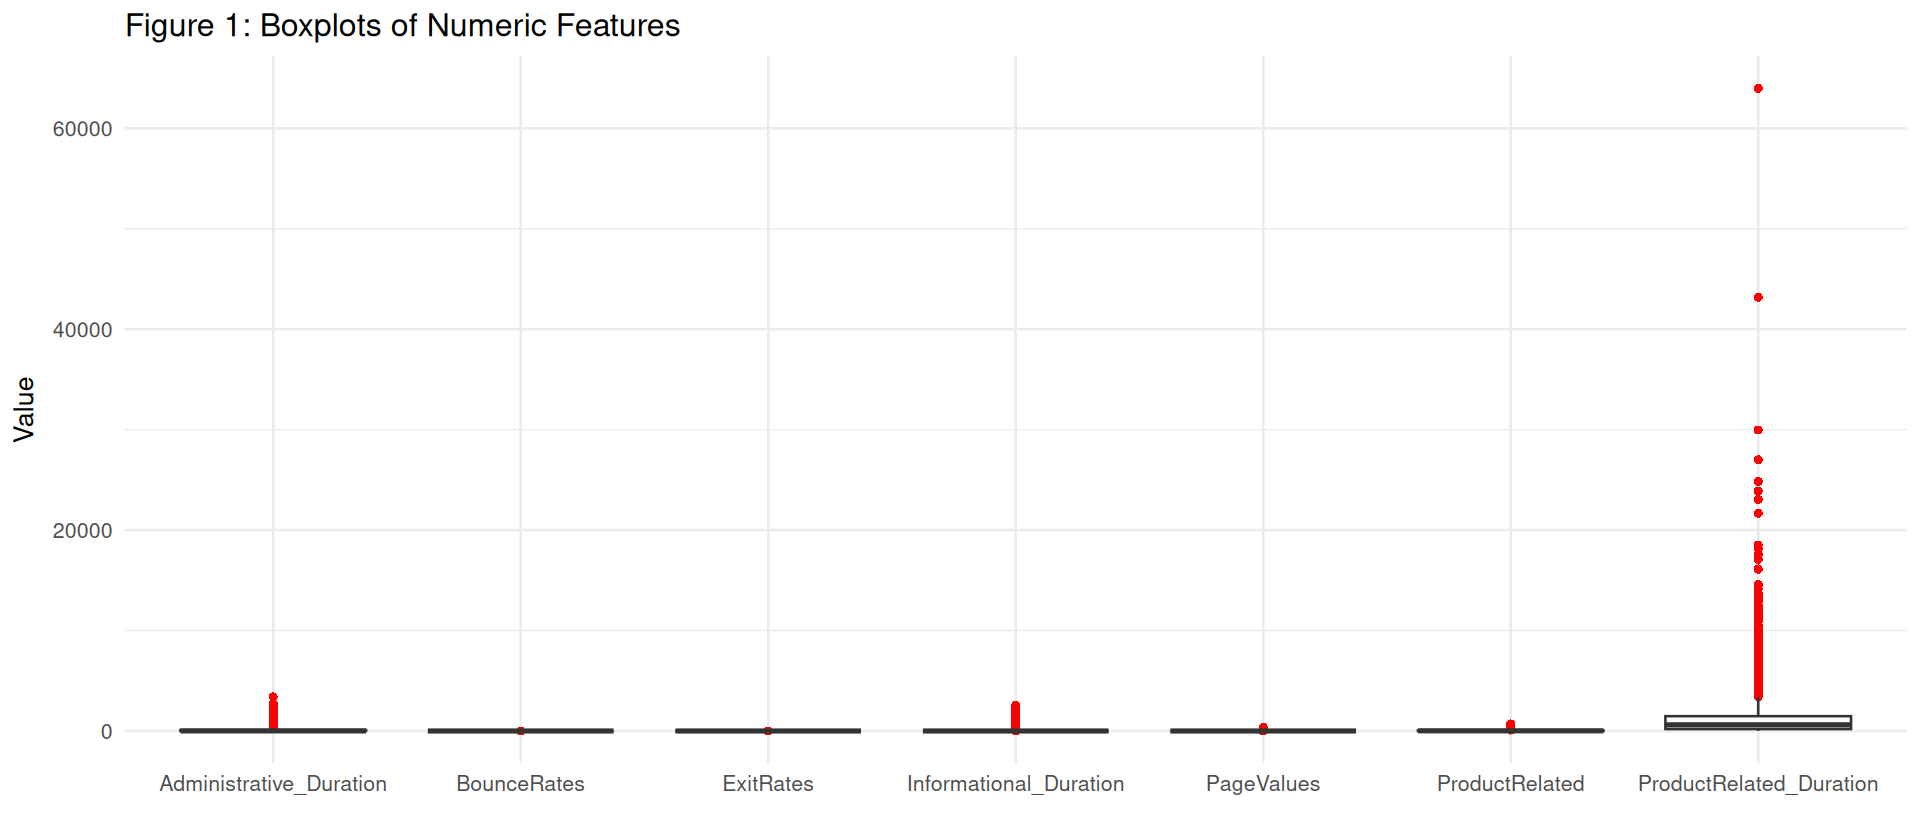

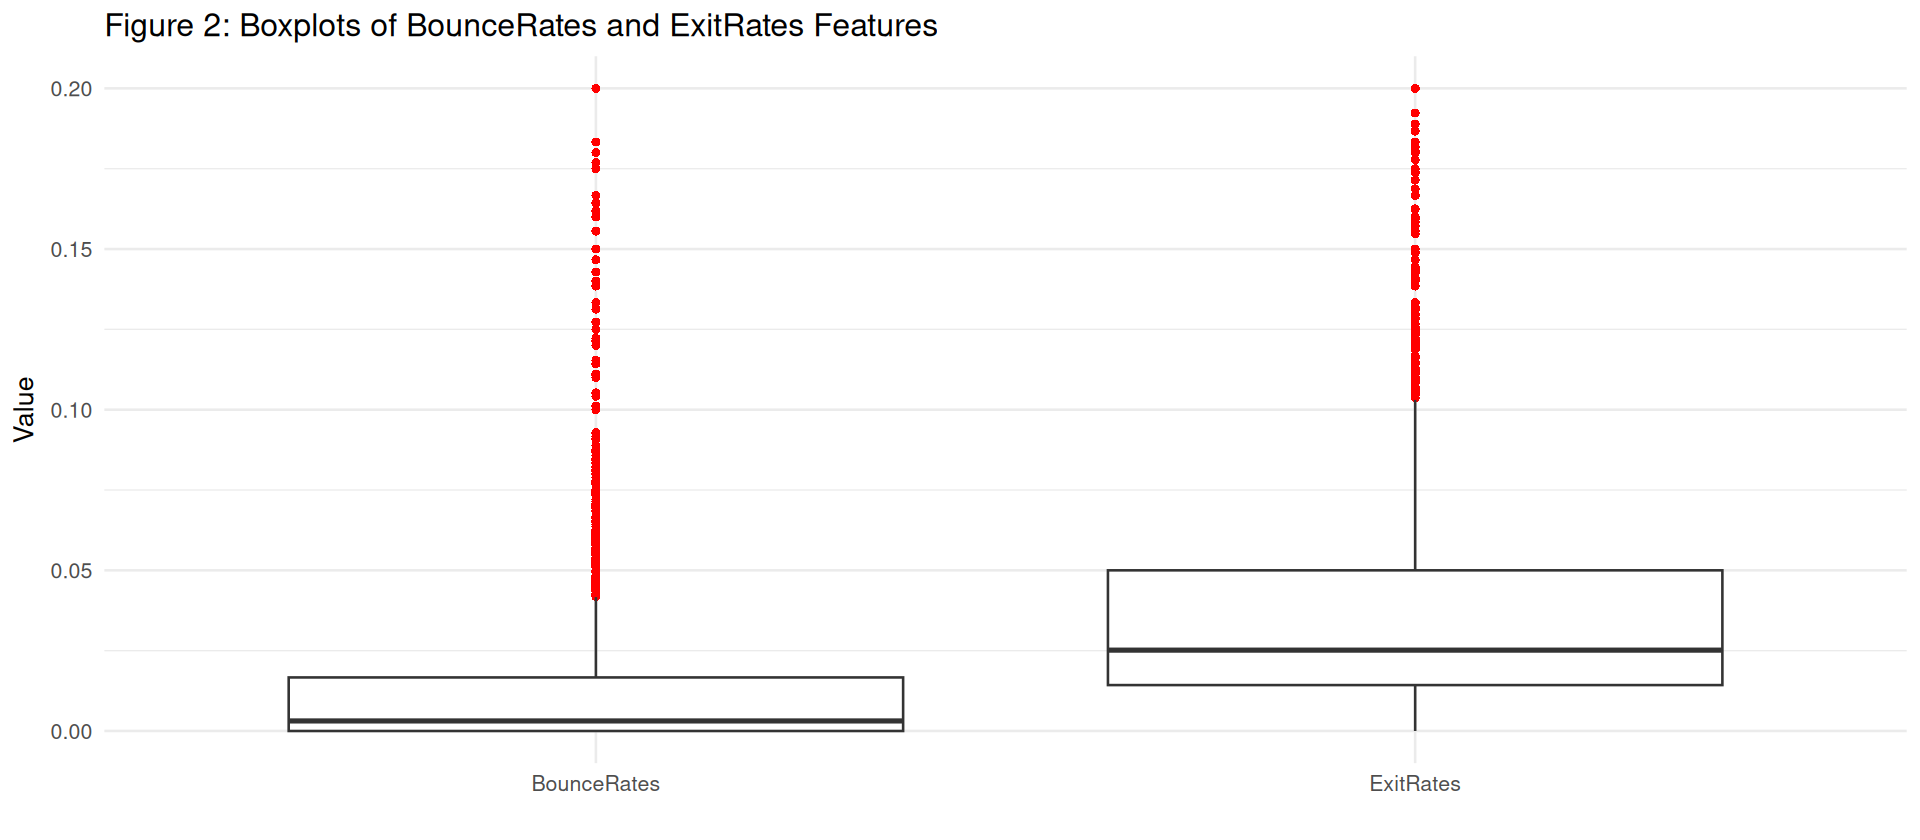

In [13]:
# Check numerical feature boxplots
numeric_shoppers_train <- cleaned_cat_shoppers_train %>%
    select(where(is.numeric)) %>%
    pivot_longer(
        cols = everything(),
        names_to = "Variable",
        values_to = "Value"
    )

numeric_shoppers_train_small <- numeric_shoppers_train %>%
    filter(Variable == "BounceRates" | Variable == "ExitRates")

options(repr.plot.width = 16, repr.plot.height = 7)
ggplot(numeric_shoppers_train, aes(Variable, Value)) + 
    geom_boxplot(outlier.colour = "red", outlier.shape = 16) + 
    theme_minimal(base_size = 16) + 
    theme() +
    labs(
        title = "Figure 1: Boxplots of Numeric Features",
        y = "Value",
        x = ""
    )

ggplot(numeric_shoppers_train_small, aes(Variable, Value)) + 
    geom_boxplot(outlier.colour = "red", outlier.shape = 16) + 
    theme_minimal(base_size = 16) + 
    theme() +
    labs(
        title = "Figure 2: Boxplots of BounceRates and ExitRates Features",
        y = "Value",
        x = ""
    )

From the boxplots in `Figure 1`, it appears that the outliers severely skew the numerical features in the training set. <br>
This can affect the linearity of the model so we will apply a `log1p(x)` transformation to the numerical features. <br>
We exclude `BounceRates` and `ExitRates` since the skew is not as severe. 

In [14]:
# Fix numeric features
cleaned_shoppers_train <- cleaned_cat_shoppers_train %>%
    mutate(
        Administrative_Duration = log1p(Administrative_Duration),
        Informational_Duration = log1p(Informational_Duration),
        PageValues = log1p(PageValues),
        ProductRelated = log1p(ProductRelated),
        ProductRelated_Duration = log1p(ProductRelated_Duration)
    )

# Again, we apply the same transformation to the test set
cleaned_shoppers_test <- cleaned_cat_shoppers_test %>%
    mutate(
        Administrative_Duration = log1p(Administrative_Duration),
        BounceRates = log1p(BounceRates),
        ExitRates = log1p(ExitRates),
        Informational_Duration = log1p(Informational_Duration),
        PageValues = log1p(PageValues),
        ProductRelated = log1p(ProductRelated),
        ProductRelated_Duration = log1p(ProductRelated_Duration)
    )

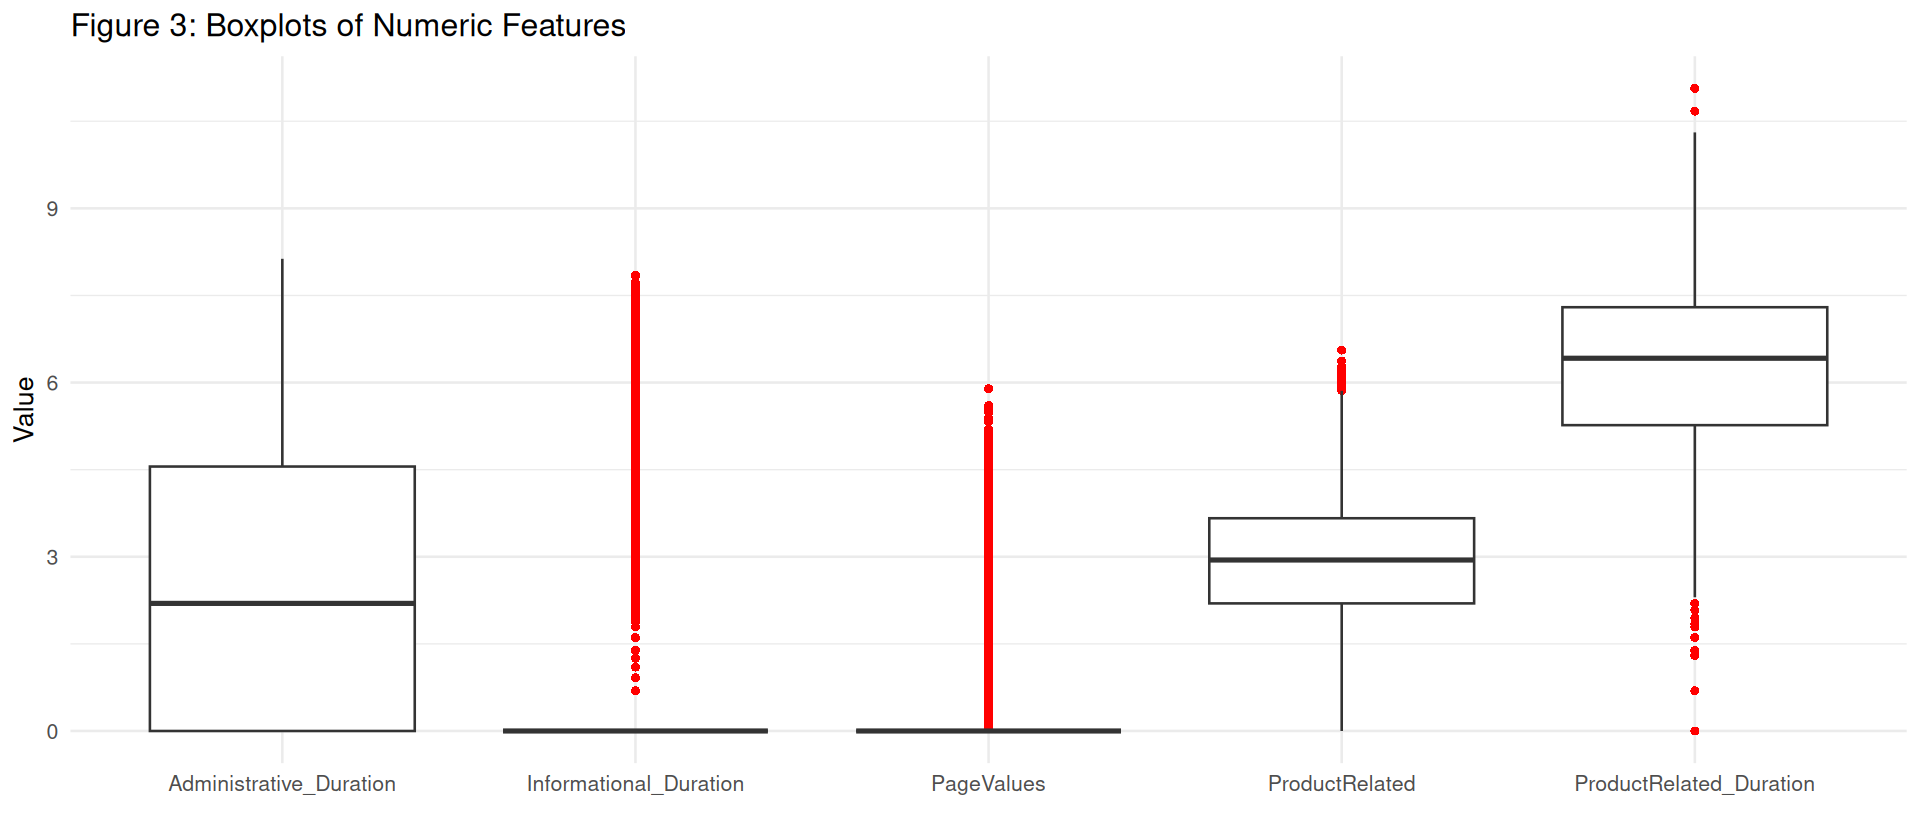

In [15]:
# Retry numeric visualization of boxplots
cleaned_numeric_shoppers_train_long <- cleaned_shoppers_train %>%
    select(where(is.numeric)) %>%
    select(-BounceRates, -ExitRates) %>%
    pivot_longer(
        cols = everything(),
        names_to = "Variable",
        values_to = "Value"
    )

ggplot(cleaned_numeric_shoppers_train_long, aes(Variable, Value)) + 
    geom_boxplot(outlier.colour = "red", outlier.shape = 16) + 
    theme_minimal(base_size = 16) + 
    theme() +
    labs(
        title = "Figure 3: Boxplots of Numeric Features",
        y = "Value",
        x = ""
    )

After applying the transformation, the plots appear more centred though there are still a few rough spots. <br>
This should be sufficient to continue the analysis. <br>
Next, we would like to explore some obvious trends. We will first isolate variables of interest and develop some visualizations. 

In [16]:
# Prepare Visualization Data
binned_purchase_rate_shoppers_train <- cleaned_shoppers_train %>%
    select(Weekend, Revenue, ProductRelated, ExitRates, SpecialDay) %>%
    mutate(
        Weekend = as.logical(Weekend),
        Revenue_num = if_else(Revenue == "Yes", 1, 0)
    )

One interesting trend is examining how purchase rates vary by the number of visits to product related pages. <br>
We can enhance the visualization by examining if the trend is consistent across weekends and weekdays.

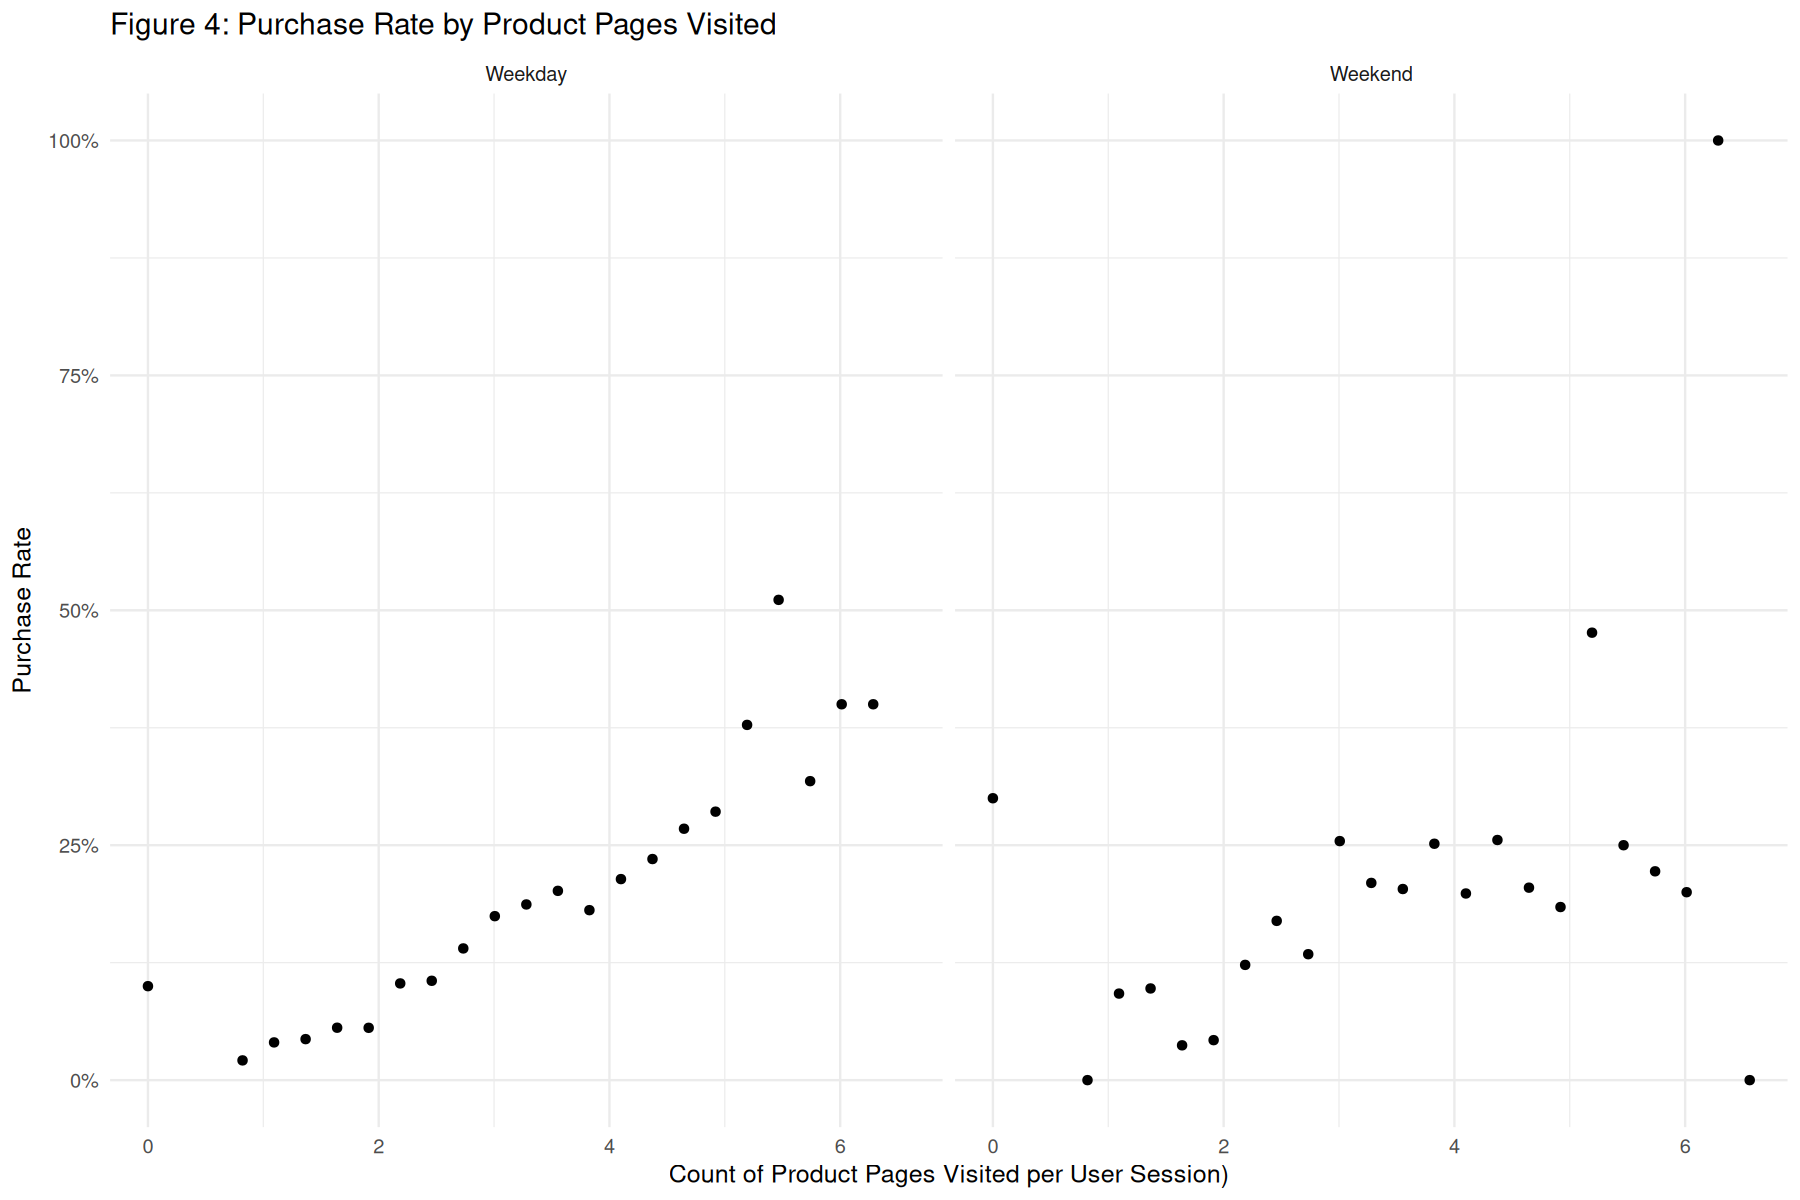

In [17]:
# Explore Purchase Rate by product pages
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(binned_purchase_rate_shoppers_train, aes(ProductRelated, Revenue_num)) + 
    stat_summary_bin(fun = mean, bins = 25, geom = "point") + 
    facet_wrap(~ Weekend, labeller = as_labeller(c(`FALSE`="Weekday", `TRUE`="Weekend"))) + 
    scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) + 
    labs(title = "Figure 4: Purchase Rate by Product Pages Visited",
         x = "Count of Product Pages Visited per User Session)",
         y = "Purchase Rate") +
    theme_minimal(base_size = 15)

From `Figure 4`, it appears that there is a positive trend between purchase rate and number of product pages visited. <br>
It is also consistent across weekends and weekdays. This is expected since users may feel more attracted to a purchase the longer they engage with the website. <br>
It could very well also be because users need to engage with the website longer to compare options when a decision to purchase has already been made. <br><br>
Next, we can explore how exit rates directly affect the purchase outcome and compared across . 

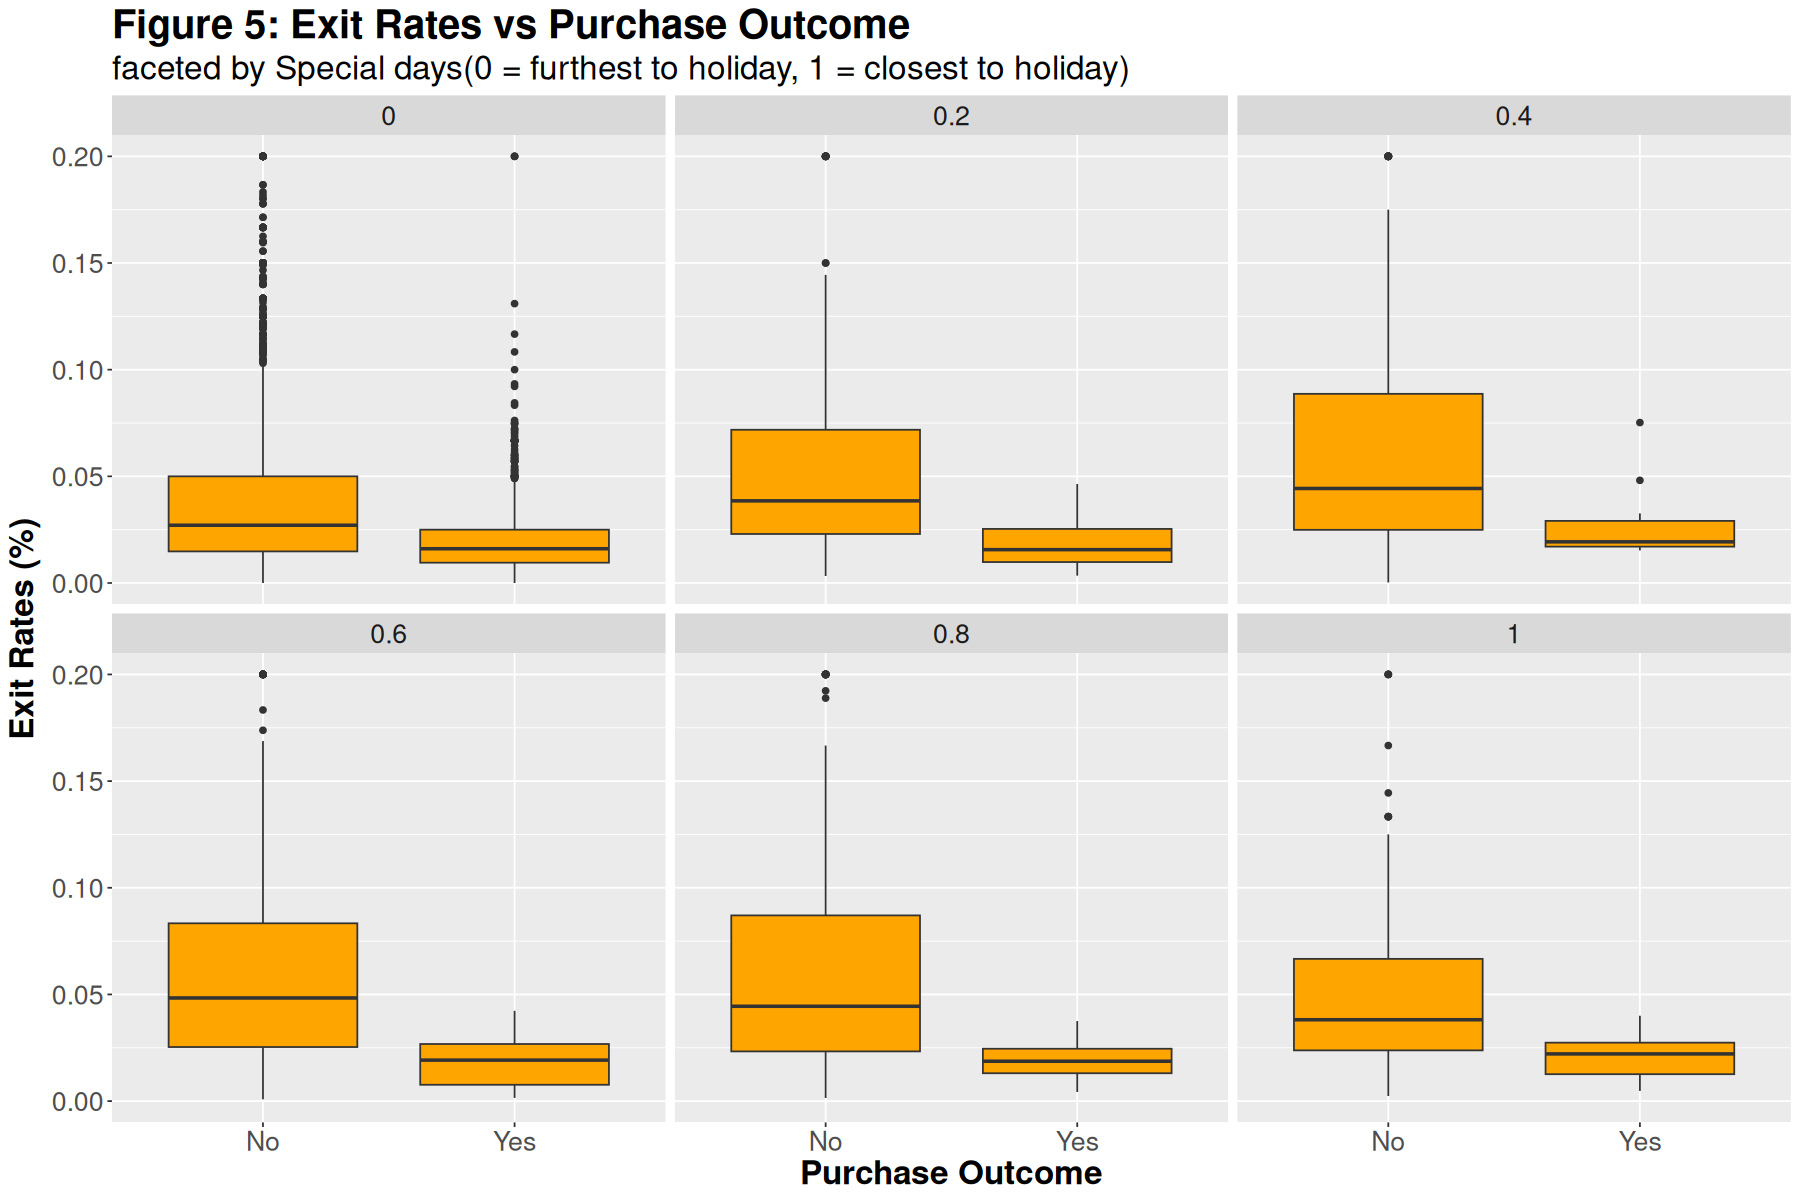

In [18]:
# Exit Rates vs Purchase Outcome
ggplot(binned_purchase_rate_shoppers_train, aes(Revenue, ExitRates)) +
    geom_boxplot(fill = "orange") + 
    facet_wrap(~ SpecialDay) +
    labs(
        title = "Figure 5: Exit Rates vs Purchase Outcome",
        subtitle = "faceted by Special days(0 = furthest to holiday, 1 = closest to holiday)",
        x = "Purchase Outcome",
        y = "Exit Rates (%)"
    ) + 
    theme(
        text = element_text(size = 20),
        plot.title = element_text(face = "bold"),
        axis.title = element_text(face = "bold")
    )

From `Figure 5`, it appears that there is a strong correlation between a high exit rate and the decision not to purchase.<br>
This is displayed by the median of the box plots being consistently higher in the "No" purchase outcome than the "Yes" purchase outcome. <br>
This could be because the decision to purchase has already been made before ending the user session. <br>
The plots also appear to have increase variance and gap between medians as it gets closer to a "special day". <br><br>

This concludes the EDA and allows us to move on to the Analysis section to build the LASSO Logistic Regression model.

### Methods

Before building the logistic regression model, the numeric features should be scaled to maintain consistent importance during analysis.

In [19]:
# Prepare Data
train_scaled <- cleaned_shoppers_train %>%
    mutate(across(where(is.numeric), scale))

test_scaled <- cleaned_shoppers_test %>%
    mutate(across(where(is.numeric), scale))

x_train <- train_scaled %>%
    select(-Revenue) %>%
    model.matrix(~ ., data = .) %>%
    .[, -1]
y_train <- as.numeric(train_scaled$Revenue)

x_test <- test_scaled %>%
    select(-Revenue) %>%
    model.matrix(~ ., data = .) %>%
    .[, -1]

y_test <- as.numeric(test_scaled$Revenue)

We should also ensure the test set has the same columns as the training set for consistency.

In [20]:
zero_mat <- matrix(0, nrow = nrow(x_test), ncol = 1)
colnames(zero_mat) <- "Informational16"
x_test <- cbind(x_test, zero_mat)
x_test <- x_test[, colnames(x_train)]

We are finally ready to fit a LASSO Logistic Regression model with the following steps.
1. Fit an initial LASSO Logistic Regression model using the training data to get the best `lambda` hyperparameter
2. Fit the final model using the previous step's result.

In [21]:
# 1. Fit an initial LASSO Logistic Regression Model on training data
cv_lasso <- cv.glmnet(x_train, y_train, family = "binomial", alpha = 1, type.measure = "auc")

cv_lasso_auc <- max(cv_lasso$cvm)
print(paste("Best Cross-Validation AUC:", cv_lasso_auc))

[1] "Best Cross-Validation AUC: 0.916080585181335"


In [22]:
# 2. Fit final model 
final_lasso <- glmnet(x_train, y_train, family = "binomial", alpha = 1, lambda = cv_lasso$lambda.min)
lasso_test_pred <- predict(final_lasso, newx = x_test, s = "lambda.min", type = "response")

### Results

With the final model, we can evaluate our performance against the original target labels. <br>
We will do this with the following figures: 
- Confusion Matrix + Statistics
- ROC curve Visualization 

In [23]:
# Display confusion matrix
roc_lasso_test <- roc(cleaned_shoppers_test$Revenue, as.numeric(lasso_test_pred), levels = c("No", "Yes"), direction = "<")
lasso_test_auc <- auc(roc_lasso_test)
lasso_test_class <- factor(ifelse(as.numeric(lasso_test_pred) > 0.5, "Yes", "No"), levels = c("No", "Yes"))

cat("Figure 6:")
lasso_test_cm <- confusionMatrix(lasso_test_class, factor(cleaned_shoppers_test$Revenue, levels = c("No", "Yes")), positive = "Yes")
print(lasso_test_cm)

Figure 6:Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1993  158
       Yes   84  211
                                          
               Accuracy : 0.9011          
                 95% CI : (0.8885, 0.9126)
    No Information Rate : 0.8491          
    P-Value [Acc > NIR] : 2.360e-14       
                                          
                  Kappa : 0.5791          
                                          
 Mcnemar's Test P-Value : 2.697e-06       
                                          
            Sensitivity : 0.57182         
            Specificity : 0.95956         
         Pos Pred Value : 0.71525         
         Neg Pred Value : 0.92655         
             Prevalence : 0.15086         
         Detection Rate : 0.08626         
   Detection Prevalence : 0.12061         
      Balanced Accuracy : 0.76569         
                                          
       'Positive' Class : Yes             
               

[1] "Figure 7: Test AUC for final Lasso model: 0.926"


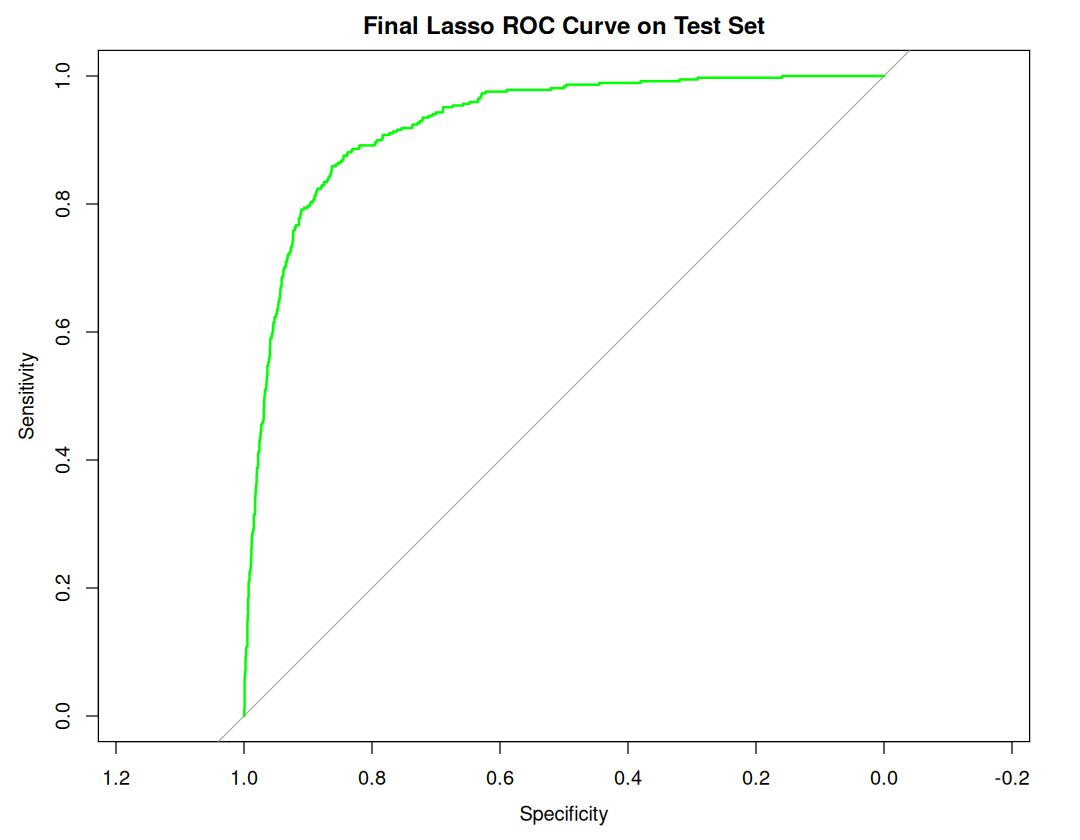

In [24]:
# Display Final ROC Curve
lasso_test_auc <- auc(roc_lasso_test)
print(paste("Figure 7: Test AUC for final Lasso model:", round(lasso_test_auc, 3)))

options(repr.plot.width = 9, repr.plot.height = 7)
plot(
    roc_lasso_test,
    col = "green",
    lwd = 2,
    main = "Final Lasso ROC Curve on Test Set"
)

**Table 10** Metrics from Confusion Matrix:
| Metric | Value|
| ------ | ---- |
| Accuracy | 90.1% |
| Sensitivity | 57.5% |
| Specificity | 95.9% |
| AUC | 92.5% |
| NIR | 84.9% |
| McNemar's Test P-Value | ~0% |

The model has strong overall performance and is extremely proficient at identifying the negative class but struggles with the positive class. This is shown through the strong specificity and relatively high accuracy but very low sensitivity. The final metric AUC explains that the model does understand the separation between classes but certain thresholds may need adjustments for the positive class. <br> 
However, since the results are not as impressive since the no-information rate is high. This is not to entirely dismiss the results as the McNemar's Test p-value is sufficiently small to render the results significant.

## Discussion

This analysis explored whether shopper session characteristics can predict online purchase intent (whether a session ends in a transaction). The dataset shows a **strong class imbalance**, with far more sessions resulting in no purchase, which may lead to a biased model that more likely to predict 'no purchase' since it learns more pattern from no purchase. 

During preprocessing, several numerical features such as `Administrative`, `Informational`, and `SpecialDay` were reclassified as categorical variables because they contained very few unique values. Rare categories in categorical variables were also combined or grouped when they represented less than 1% of observations to reduce instability in logistic regression. Additionally, many numerical features showed severe skewness and outliers, so a **log1p transformation** was applied to improve data distribution and better satisfy the linearity assumption of logistic regression. These preprocessing steps improve the reliability of the analysis and provide a strong foundation for our model setup.  

Exploratory data analysis revealed several behavioral patterns. The number of **product-related pages visited showed a positive relationship with purchase rates**. Conversely, sessions with **higher exit rates were strongly associated with non-purchase outcomes**.

A **LASSO logistic regression model** was used to predict purchase outcomes. The model demonstrated strong overall performance in identifying non-purchasing sessions, reflected by **high specificity and accuracy**, but struggled to detect purchasing sessions, resulting in **low sensitivity**. This is likely because the biased training data as far more `no purchase` data points are included. Although the AUC indicates that the model captures meaningful separation between the classes, the high no-information rate suggests that **prediction remains challenging due to class imbalance**. Nevertheless, the small McNemar’s test p-value indicates that the model performs significantly better than random guessing. Future work could explore techniques to debias the model (e.g. reweighting features, equalized odds), resampling techniques, or alternative models to improve detection of the minority purchase class.

## References

Esmeli, R., Bader-El-Den, M., & Abdullahi, H. (2021). Towards early purchase 
intention prediction in online session based retailing systems. *Electronic 
Markets*, 31, 697–715. https://doi.org/10.1007/s12525-020-00448-x

Sakar, C.O., Polat, S.O., Katircioglu, M., & Kastro, Y. (2019). Real-time 
prediction of online shoppers' purchasing intention using multilayer perceptron 
and LSTM recurrent neural networks. *Neural Computing and Applications*, 31, 
6893–6908. https://doi.org/10.1007/s00521-018-3523-0

UCI Machine Learning Repository: Online Shoppers Purchasing Intention Dataset.  
https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

Zeng, L., Cook, R., & Wen, L. (2022). A classification for complex imbalanced 
data in disease screening and early diagnosis. *Statistics in Medicine*, 41(16), 
3006–3029. https://doi.org/10.1002/sim.9442